In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyoti.sparse as oti
from jetgp.full_degp.degp import degp
import jetgp.utils as utils
import time

plt.rcParams.update({'font.size': 12})

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


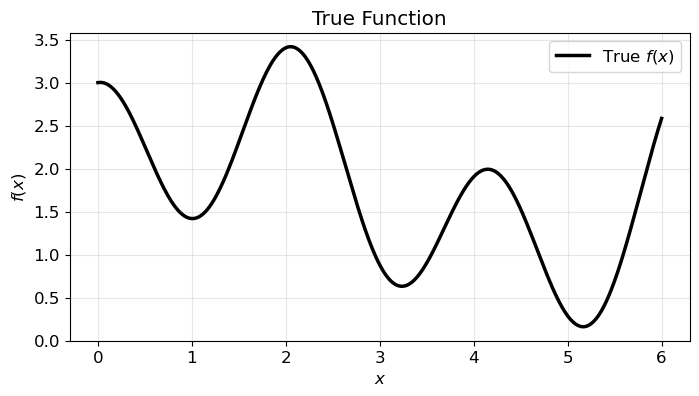

In [2]:
# Domain
lb_x, ub_x = 0, 6.0
num_plot_pts = 500
X_plot = np.linspace(lb_x, ub_x, num_plot_pts).reshape(-1,1)

# Define function
def true_function(X, alg=oti):
    x = X[:, 0]
    return alg.exp(-x) + alg.sin(x) + alg.cos(3 * x) + 0.2 * x + 1.0

# Compute function values
y_plot = true_function(X_plot, alg=np)

# Plot
plt.figure(figsize=(8,4))
plt.plot(X_plot, y_plot, 'k-', lw=2.5, label='True $f(x)$')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('True Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [3]:
num_training_pts = 4
num_test_pts = 100
orders_to_test = [0, 1, 2, 4]

kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 150
normalize_data = False

In [4]:
def train_and_evaluate_degps(X_train, X_test, true_function, order):
    print(f"Processing Order {order}...")
    start_time = time.time()

    # Generate Training Data with Derivatives
    der_indices = utils.gen_OTI_indices(1, order)
    X_train_pert = oti.array(X_train) + oti.e(1, order=order)
    derivative_locations = []
    for i in range(len(der_indices)):
        for j in range(len(der_indices[i])):
            derivative_locations.append([i for i in range(len(X_train ))])
    y_train_hc = true_function(X_train_pert)

    y_train_list = [y_train_hc.real]
    for i in range(len(der_indices)):
        for j in range(len(der_indices[i])):
            derivative = y_train_hc.get_deriv(der_indices[i][j]).reshape(-1, 1)
            y_train_list.append(derivative)

    # Initialize and train DEGP model
    gp = degp(
        X_train, y_train_list, order, n_bases=1, der_indices=der_indices,derivative_locations = derivative_locations,
        normalize=normalize_data, kernel=kernel, kernel_type=kernel_type
    )

    params =gp.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = True
    )

    # Predict function and derivatives
    y_pred_full, y_var_full = gp.predict(X_test, params, calc_cov=True, return_deriv=False)

    # Compute MSE for function predictions only
    y_pred_func = y_pred_full[:num_test_pts]
    y_true_flat = true_function(X_test, alg=np).ravel()
    mse = np.mean((y_pred_func.ravel() - y_true_flat)**2)

    print(f"  MSE: {mse:.6f}, Time: {time.time() - start_time:.2f}s")
    return {
        'y_pred_full': y_pred_full,
        'y_var_full': y_var_full,
        'mse': mse,
        'time': time.time() - start_time,
        'n_observations': sum(len(y) for y in y_train_list)
    }

In [5]:
X_train = np.linspace(lb_x, ub_x, num_training_pts).reshape(-1, 1)
X_test = np.linspace(lb_x, ub_x, num_test_pts).reshape(-1, 1)

results = {}
for order in orders_to_test:
    results[order] = train_and_evaluate_degps(X_train, X_test, true_function, order)

Processing Order 0...
Gen 1: best f=8.555515100592274


Gen 2: best f=8.555515100592274
Gen 3: best f=8.555515100592274
Gen 4: best f=8.555515100592274
Gen 5: best f=8.199102832031281
Gen 6: best f=8.199102832031281
Gen 7: best f=8.199102832031281
Gen 8: best f=8.108279627133218
Gen 9: best f=8.108279627133218
Gen 10: best f=8.060756341668167
Gen 11: best f=8.060756341668167
Gen 12: best f=8.060756341668167
Gen 13: best f=8.053839290000669
Gen 14: best f=8.053839290000669


Gen 15: best f=8.053556753787092
  MSE: 1.490532, Time: 0.46s
Processing Order 1...
Gen 1: best f=23.265770371412046
Gen 2: best f=23.265770371412046
Gen 3: best f=18.860075205895782
Gen 4: best f=18.860075205895782
Gen 5: best f=18.860075205895782
Gen 6: best f=18.860075205895782
Gen 7: best f=18.718450216471183


Gen 8: best f=18.718450216471183
Gen 9: best f=18.718450216471183
Gen 10: best f=18.663849108710146
Gen 11: best f=18.663849108710146
Gen 12: best f=18.663849108710146
Gen 13: best f=18.663849108710146
Gen 14: best f=18.663849108710146
Gen 15: best f=18.663849108710146
  MSE: 0.358957, Time: 0.39s
Processing Order 2...


Gen 1: best f=30.7077866284139
Gen 2: best f=30.657936786251177
Gen 3: best f=30.657936786251177
Gen 4: best f=30.657936786251177
Gen 5: best f=29.66586574120022
Gen 6: best f=29.66586574120022
Gen 7: best f=29.32791640335701
Gen 8: best f=29.32791640335701
Gen 9: best f=29.32791640335701


Gen 10: best f=28.898506157593737
Gen 11: best f=28.883194646122618
Gen 12: best f=28.883194646122618
Gen 13: best f=28.883194646122618
Gen 14: best f=28.775505908596926
Gen 15: best f=28.775505908596926
  MSE: 0.000147, Time: 0.40s
Processing Order 4...
Gen 1: best f=49.39731990574795


Gen 2: best f=41.41641841823673
Gen 3: best f=41.41641841823673
Gen 4: best f=34.111617946575386
Gen 5: best f=34.111617946575386
Gen 6: best f=34.111617946575386
Gen 7: best f=34.111617946575386
Gen 8: best f=34.111617946575386
Gen 9: best f=33.87589338245215
Gen 10: best f=33.87589338245215
Gen 11: best f=33.87589338245215


Gen 12: best f=33.87589338245215
Gen 13: best f=33.30821780593601
Gen 14: best f=33.30821780593601
Gen 15: best f=33.30821780593601
  MSE: 0.000000, Time: 0.41s


In [6]:
print("RESULTS SUMMARY")
print("="*60)
print(f"{'Order':<8}{'MSE':<12}{'Time (s)':<10}{'Observations'}")
print("-"*60)
for order, r in results.items():
    print(f"{order:<8}{r['mse']:<12.6f}{r['time']:<10.2f}{r['n_observations']}")

RESULTS SUMMARY
Order   MSE         Time (s)  Observations
------------------------------------------------------------
0       1.490532    0.46      4
1       0.358957    0.39      8
2       0.000147    0.40      12
4       0.000000    0.41      20


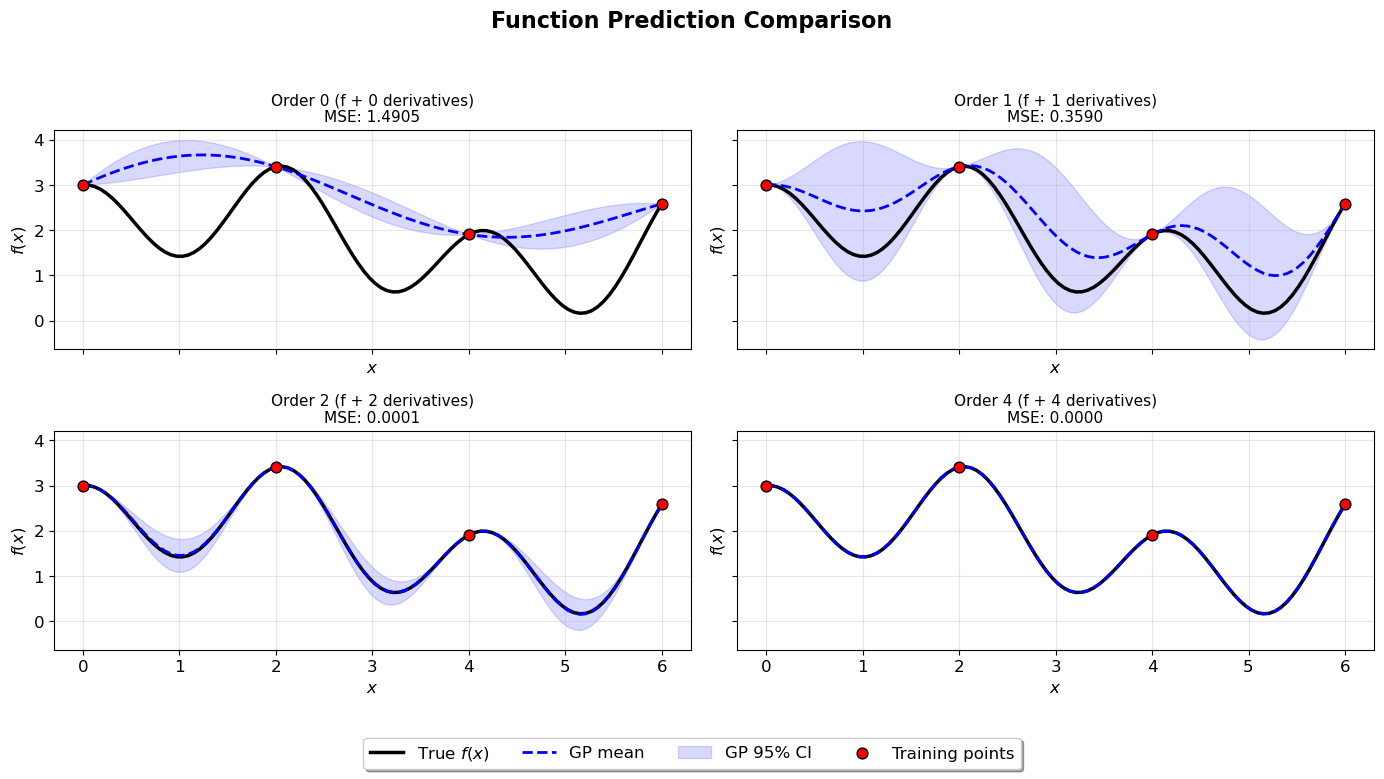

In [7]:
import math

n_orders = len(orders_to_test)
n_cols = 2
n_rows = math.ceil(n_orders / n_cols)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 4*n_rows), sharex=True, sharey=True)
axs = axs.flatten()
y_true = true_function(X_test, alg=np)
y_train_func = true_function(X_train, alg=np)

for i, order in enumerate(orders_to_test):
    ax = axs[i]
    r = results[order]
    y_pred = r['y_pred_full'][:num_test_pts]
    y_var = r['y_var_full'][:num_test_pts]

    ax.plot(X_test, y_true, 'k-', lw=2.5, label="True $f(x)$")
    ax.plot(X_test, y_pred.flatten(), 'b--', lw=2, label="GP mean")
    ax.fill_between(
        X_test.ravel(),
        y_pred.ravel() - 2*np.sqrt(y_var.ravel()),
        y_pred.ravel() + 2*np.sqrt(y_var.ravel()),
        color='blue', alpha=0.15, label='GP 95% CI'
    )
    ax.scatter(X_train, y_train_func, c='red', s=60, zorder=5,
               edgecolors='black', linewidth=1, label="Training points")

    # Title with order and number of derivatives
    num_derivatives = sum(len(group) for group in utils.gen_OTI_indices(1, order))
    ax.set_title(f"Order {order} (f + {num_derivatives} derivatives)\nMSE: {r['mse']:.4f}", fontsize=11)
    ax.set(xlabel="$x$", ylabel="$f(x)$")
    ax.grid(True, alpha=0.3)

# Hide any extra subplots if n_orders < n_rows*n_cols
for j in range(i+1, n_rows*n_cols):
    fig.delaxes(axs[j])

fig.suptitle('Function Prediction Comparison', fontsize=16, fontweight='bold', y=0.98)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=len(handles), frameon=True, fancybox=True, shadow=True)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()